# Target-gene coefficient similarity

**Question:** do two target genes get *modulated the same way* by the same modulators, cell-by-cell?

Each trained gene `G` has a per-cell coefficient map for every modulator, stored in
`adata.obsm['beta_<G>']` (`cells x modulators`) with names in
`adata.uns['beta_modulators'][G]`. Modulator group is read from the name separator
(`@`=metab, `$`=lr, `#`=ltf, none=tf) — same convention as `beta_analysis.py`.

### The one primitive: per-modulator similarity
For a pair of genes and one modulator, take each gene's per-cell coefficient vector
(absent modulator / unfit cell = 0). With `standardize=True` we z-score each vector on
its own (never pooling scales across modulators) and the value is the **Pearson r ∈ [-1, 1]**
of the two genes' spatial coefficient maps for that modulator. `standardize=False` gives the
raw dot product.

### Aggregate to a single number
`similarity()` collapses the per-modulator vector to one score:
- standardized → **cosine similarity of the standardized maps** = (Σ per-modulator r over
  shared modulators) / √(nA·nB), where nA, nB are each gene's number of spatially-*varying*
  modulators. Symmetric, self-similarity = 1, bounded in [-1, 1], and it "divides by both"
  genes' modulator counts, so a pair that shares few modulators is penalized.
- raw → sum of the per-modulator dots (Frobenius block dot). This measures *magnitude*, not
  shape: its diagonal is Σβ² (large for big-β genes, rounds to ~0 for tiny-β genes) rather
  than 1. That magnitude-vs-shape contrast is exactly why the standardized score is the
  meaningful one — see the diagnostic below the grids.

> Data source: `spacetravlr_adata.h5ad` (built once by `beta_analysis.betas_to_adata`),
> which lives on Savio — the real cells below run there. The synthetic cell needs only
> numpy/pandas and runs anywhere.

In [1]:
import sys
from pathlib import Path
# Make the repo root importable regardless of CWD or machine.
_start = Path.cwd()
_root = next((p for p in (_start, *_start.parents)
              if (p / ".git").exists() or (p / "setup.py").exists()), _start)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## The functions

In [2]:
# Modulator group from the name separator (matches beta_analysis.SEPARATORS).
SEPARATORS = {"@": "metab", "$": "lr", "#": "ltf"}


def _group(modulator):
    """'metab', 'lr', 'ltf', or 'tf' (no separator)."""
    for sep, name in SEPARATORS.items():
        if sep in modulator:
            return name
    return "tf"


def gene_block(adata, gene, group="metab"):
    """One gene's coefficients as a (cells x modulators) DataFrame, restricted to `group`.

    `group` is one of 'metab', 'lr', 'ltf', 'tf', or None (=all). Unfit cells are NaN in
    obsm; we fill them (and any absent modulator) with 0 — 'not included' means 0.
    """
    names = list(adata.uns["beta_modulators"].get(gene, []))
    keep = [i for i, n in enumerate(names) if group is None or _group(n) == group]
    block = pd.DataFrame(
        np.asarray(adata.obsm[f"beta_{gene}"])[:, keep],
        index=pd.Index(adata.obs_names),
        columns=[names[i] for i in keep],
    )
    return block.fillna(0.0)


def _zscore(v):
    """z-score a 1-D array; a constant / all-zero vector -> zeros (factor contributes nothing)."""
    sd = v.std()  # numpy std => population (ddof=0)
    if sd == 0:
        return np.zeros_like(v)
    return (v - v.mean()) / sd

In [3]:
def factor_sims(adata, gene_a, gene_b, group="metab", standardize=True):
    """Per-modulator similarity between two genes' coefficient maps (the reusable primitive).

    Returns a Series indexed by modulator. Each value is the Pearson r in [-1, 1]
    (standardize=True) or the raw dot product (False) of the two genes' per-cell
    coefficients for that modulator. Each factor is z-scored on its own, so scales are
    never pooled across factors/groups. A factor absent (or constant) in either gene is 0.
    """
    A = gene_block(adata, gene_a, group)
    B = gene_block(adata, gene_b, group)
    mods = A.columns.union(B.columns)
    A = A.reindex(columns=mods, fill_value=0.0)
    B = B.reindex(columns=mods, fill_value=0.0)

    out = {}
    for m in mods:
        a, b = A[m].to_numpy(), B[m].to_numpy()
        if standardize:
            a, b = _zscore(a), _zscore(b)
            out[m] = float(a @ b) / len(a)  # Pearson r (0 if either factor is constant)
        else:
            out[m] = float(a @ b)
    return pd.Series(out, name=f"{gene_a}~{gene_b}")


def _n_varying(adata, gene, group="metab"):
    """Number of spatially-varying modulators of `gene` within `group`."""
    block = gene_block(adata, gene, group)
    return int((block.std(axis=0) > 0).sum())


def similarity(adata, gene_a, gene_b, group="metab", standardize=True):
    """Gene-gene similarity from the per-modulator similarities.

    standardize=True: cosine similarity of the standardized coefficient maps =
    (sum of per-modulator Pearson r over shared modulators) / sqrt(nA * nB), where
    nA, nB are each gene's count of spatially-varying modulators. Symmetric, self=1,
    in [-1, 1]; divides by BOTH genes' modulator counts so low overlap is penalized.
    Returns 0.0 if either gene has no varying modulator in the group.
    standardize=False: sum of the raw per-modulator dots (unnormalized magnitude).
    """
    v = factor_sims(adata, gene_a, gene_b, group, standardize)
    if not standardize:
        return float(v.sum())
    denom = np.sqrt(_n_varying(adata, gene_a, group) * _n_varying(adata, gene_b, group))
    return float(v.sum() / denom) if denom else 0.0

In [4]:
def similarity_grid(adata, genes, group="metab", standardize=True):
    """Symmetric genes x genes similarity DataFrame (each entry via `similarity`)."""
    genes = list(genes)
    M = np.zeros((len(genes), len(genes)))
    for i in range(len(genes)):
        for j in range(i, len(genes)):
            M[i, j] = M[j, i] = similarity(adata, genes[i], genes[j], group, standardize)
    return pd.DataFrame(M, index=genes, columns=genes)


def _heatmap(ax, mat, center0=True, annot=True):
    """Bare-bones labelled heatmap (matplotlib only). Diverging + centered at 0 for r."""
    data = mat.to_numpy(dtype=float)
    if center0:
        finite = np.abs(data[np.isfinite(data)])        # ignore NaNs (e.g. triangular mask)
        lim = (finite.max() if finite.size else 0.0) or 1.0  # empty / all-NaN / all-0 -> 1.0
        im = ax.imshow(data, cmap="RdBu_r", vmin=-lim, vmax=lim)
    else:
        im = ax.imshow(data, cmap="viridis")
    ax.set_xticks(range(mat.shape[1]), mat.columns, rotation=90)
    ax.set_yticks(range(mat.shape[0]), mat.index)
    if annot:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                if np.isfinite(data[i, j]):
                    ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", fontsize=7)
    return im


def plot_grid(mat, title="", triangular=True, center0=True):
    """Heatmap of a genes x genes similarity matrix; `triangular` masks the upper half (diag view)."""
    mat = mat.copy()
    if triangular:
        mask = np.triu(np.ones(mat.shape, bool), k=1)
        mat = mat.mask(mask)
    fig, ax = plt.subplots(figsize=(0.7 * mat.shape[1] + 2, 0.7 * mat.shape[0] + 2))
    im = _heatmap(ax, mat, center0=center0)
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title)
    fig.tight_layout()
    return fig


def plot_factor_sims(series_or_df, title="", center0=True):
    """Vector heatmap of per-factor similarities.

    Pass one `factor_sims(...)` Series, or a DataFrame (modulators x gene-pairs) built by
    concatenating several — to see *which* factors drive a correlation.
    """
    df = series_or_df.to_frame() if isinstance(series_or_df, pd.Series) else series_or_df
    fig, ax = plt.subplots(figsize=(0.7 * df.shape[1] + 2, 0.3 * df.shape[0] + 2))
    im = _heatmap(ax, df, center0=center0)
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title)
    fig.tight_layout()
    return fig

## Synthetic sanity check (runs anywhere — numpy/pandas only)

A 4-cell, 2-gene mock with hand-computed answers, so we trust the math before touching
the real data. `B`'s `GLN@SLC` map is exactly `2 x A`'s (perfectly correlated → r=1);
`A` also has a `LAC@MCT` map that `B` lacks (inactive → contributes 0).

In [5]:
from types import SimpleNamespace

mock = SimpleNamespace(
    obs_names=["c0", "c1", "c2", "c3"],
    obsm={
        # columns follow uns['beta_modulators'] order below
        "beta_GENE_A": np.array([[1.0, 1.0], [2, 0], [3, 1], [4, 0]]),  # GLN@SLC, LAC@MCT (both vary)
        "beta_GENE_B": np.array([[2.0], [4], [6], [8]]),               # GLN@SLC only (=2x A)
        "beta_GENE_C": np.array([[-2.0], [-4], [-6], [-8]]),           # GLN@SLC only (=-1x B)
    },
    uns={"beta_modulators": {
        "GENE_A": ["GLN@SLC", "LAC@MCT"], "GENE_B": ["GLN@SLC"], "GENE_C": ["GLN@SLC"],
    }},
)

v = factor_sims(mock, "GENE_A", "GENE_B", group="metab", standardize=True)
print("per-factor r:\n", v)
assert np.isclose(v["GLN@SLC"], 1.0), v["GLN@SLC"]   # perfectly correlated
assert np.isclose(v["LAC@MCT"], 0.0), v["LAC@MCT"]   # absent in B -> inactive

# standardized similarity = cosine similarity of the standardized maps:
# (sum of r over shared modulators) / sqrt(nA * nB); A has 2 varying metab modulators,
# B has 1 -> (1 + 0) / sqrt(2*1).
assert np.isclose(similarity(mock, "GENE_A", "GENE_B", standardize=True), 1 / np.sqrt(2))
# raw: dot([1,2,3,4],[2,4,6,8]) = 60; LAC@MCT dots with zeros = 0 -> unchanged
assert np.isclose(similarity(mock, "GENE_A", "GENE_B", standardize=False), 60.0)

# self-similarity = 1, symmetric, anti-correlated (coverage-penalized) = -1/sqrt(2)
assert np.isclose(similarity(mock, "GENE_A", "GENE_A", standardize=True), 1.0)
assert np.isclose(
    similarity(mock, "GENE_A", "GENE_B", standardize=True),
    similarity(mock, "GENE_B", "GENE_A", standardize=True),
)
assert np.isclose(similarity(mock, "GENE_A", "GENE_C", standardize=True), -1 / np.sqrt(2))

print("\nOK — synthetic checks pass")

per-factor r:
 GLN@SLC    1.0
LAC@MCT    0.0
Name: GENE_A~GENE_B, dtype: float64

OK — synthetic checks pass


## Apply to the melanoma dataset (Savio)

Loads the frozen `spacetravlr_adata.h5ad` and runs the grid over `FOCUS_GENES`.

In [6]:
import scanpy as sc
from metab_processing.metab_travlr_config import PROJECT_DATA_DIR, FOCUS_GENES

DATASET_NAME = "Primary_Dermal_Melanoma"
DATA_DIR = f"{PROJECT_DATA_DIR}/{DATASET_NAME}"

adata = sc.read_h5ad(f"{DATA_DIR}/spacetravlr_adata.h5ad")
adata

AnnData object with n_obs × n_vars = 112551 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', '_scvi_batch', '_scvi_labels', 'leiden_scVI_res_0.5', 'leiden_scVI_res_2.5', 'leiden_scVI_res_2', 'leiden_scVI_res_1.5', 'leiden_scVI_res_1', 'leiden_scVI_res_0.75', 'leiden_scVI_res_0.65', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.25', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.05', 'cd8', 'cd4', 't_cell', 'Tier1', 'Tier2', 'Tier3', 'Cytotoxic_CD8_score', 'Exhausted_CD8_score', 'Treg_score', 'sub_cluster_5_res_1', 'sub_cluster_5_res_0.75', 'sub_cluster_5_res_0.5', 'sub_cluster_5_res_0.37', 'sub_cluster_5_res_0.25', 'sub_cluster_5_res_0.15', 'sub_cluster_5_res_0.1', 'sub_cluster_5_res_0.05', 'sub_cluster_2_res_1', 'sub_cluster_2_res_0.75', 'sub_cluster_2_res_0

In [7]:
# Which of our focus genes were actually trained (have a betas block)?
genes = [g for g in FOCUS_GENES if g in adata.uns["beta_modulators"]]
print(f"{len(genes)}/{len(FOCUS_GENES)} focus genes present:", genes)

16/20 focus genes present: ['IL10', 'PDCD1', 'LAG3', 'IL2RA', 'CD4', 'TBP', 'CD3G', 'TOX', 'HIF1A', 'TCF7', 'ENTPD1', 'MYC', 'HAVCR2', 'CTLA4', 'CD3E', 'FOXP3']


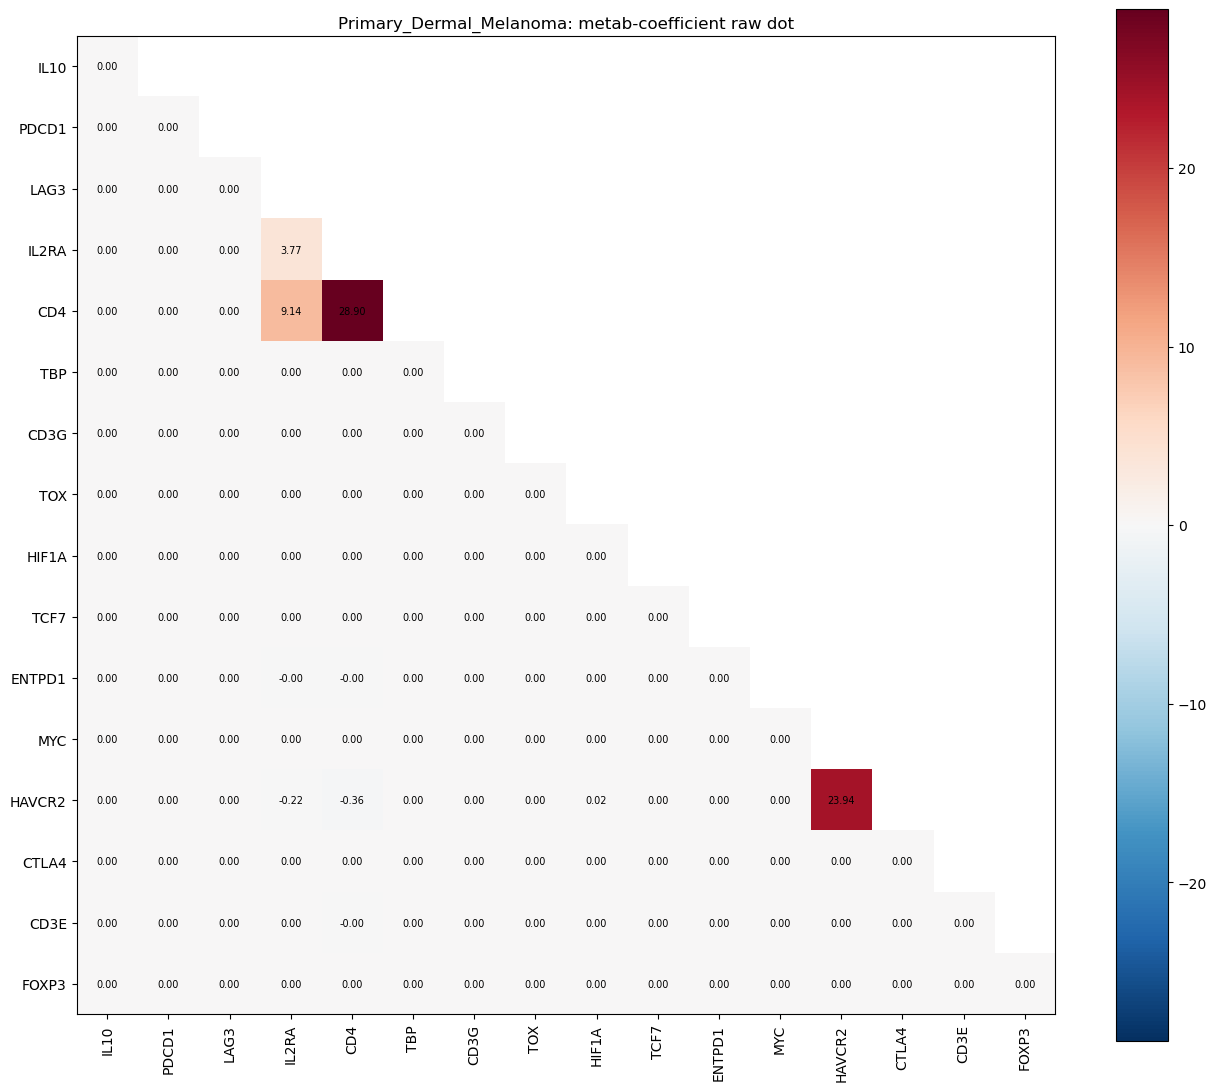

In [8]:
# Non-standardized (raw dot) grid — this is magnitude, not shape.
grid = similarity_grid(adata, genes, group="metab", standardize=False)
plot_grid(grid, title=f"{DATASET_NAME}: metab-coefficient raw dot");

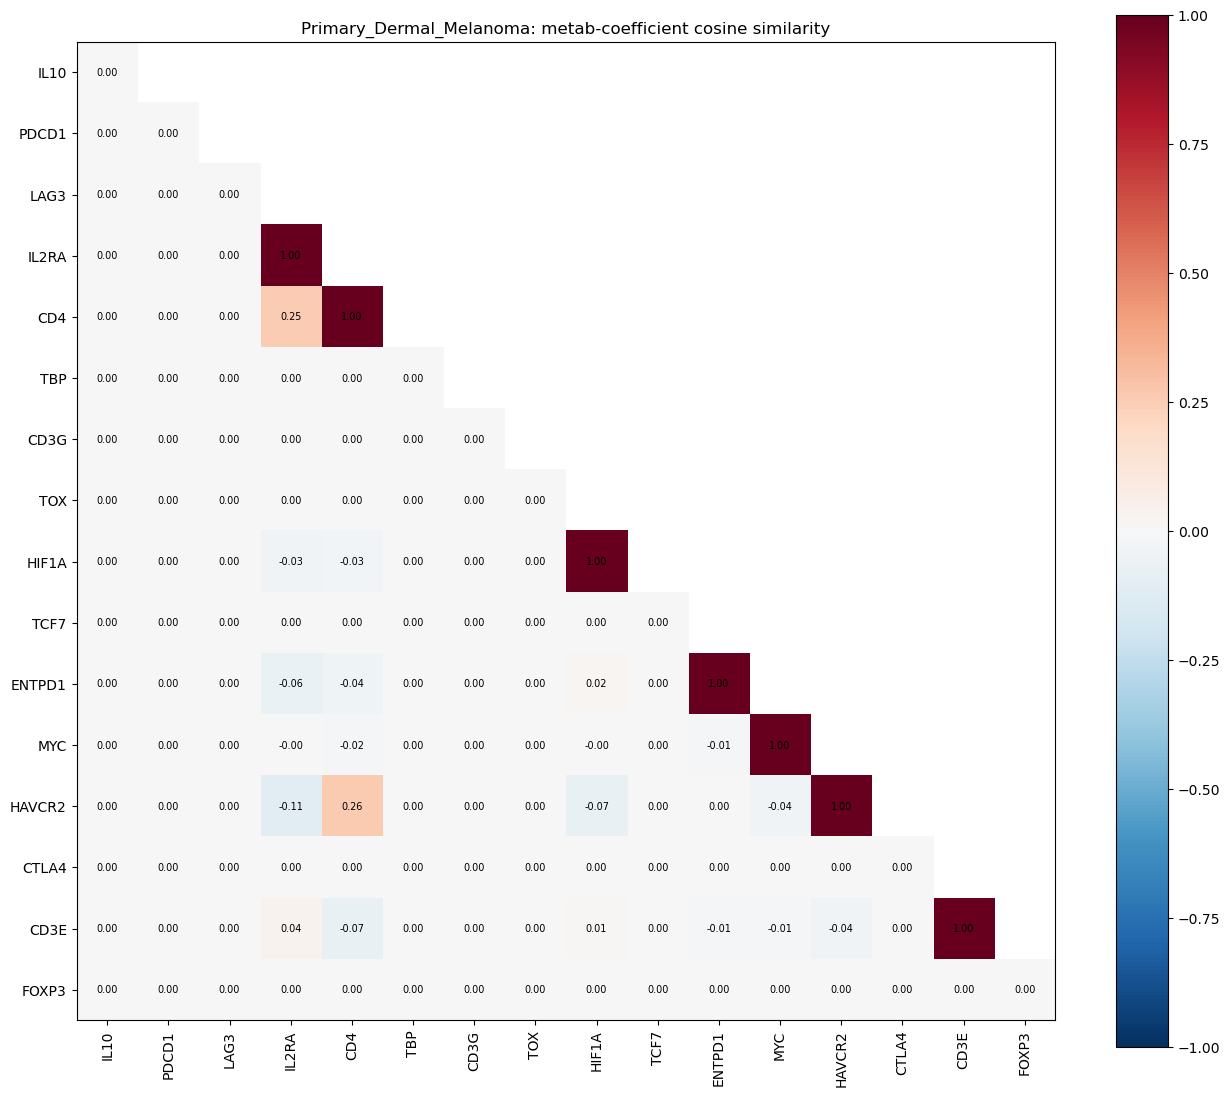

In [9]:
# Standardized grid = cosine similarity of the standardized maps (in [-1, 1]).
grid = similarity_grid(adata, genes, group="metab", standardize=True)
plot_grid(grid, title=f"{DATASET_NAME}: metab-coefficient cosine similarity");

### Why the raw diagonal reads 0 for some genes but not others

The raw (non-standardized) self-similarity of a gene is `Σ β²` over its metab modulators —
that's **magnitude**, and magnitude ≠ variance. A coefficient map like `[0.001, 0.002,
0.003]` has a near-zero sum-of-squares (prints as `0.00`) yet nonzero *variance*, so it
still correlates 1.0 with itself. The table below shows, per gene: how many metab
modulators it has, how many are spatially *varying* (drive the standardized score), and its
`Σβ²`. Genes with `n_varying ≥ 1` but tiny `sum_sq` are exactly the ones that read `1.00`
standardized and `0.00` raw on the diagonal.

In [10]:
# Magnitude vs. variance, per gene: the raw diagonal is `sum_sq`; the standardized diagonal
# is 1 whenever n_varying >= 1 (else 0). Tiny sum_sq + n_varying>=1 => raw ~0 but cosine 1.
rows = []
for g in genes:
    blk = gene_block(adata, g, "metab")
    rows.append({
        "gene": g,
        "n_metab_mods": blk.shape[1],
        "n_varying": _n_varying(adata, g, "metab"),
        "sum_sq (raw self)": float((blk.to_numpy() ** 2).sum()),
        "max_abs_beta": float(np.abs(blk.to_numpy()).max()) if blk.size else 0.0,
    })
pd.DataFrame(rows).set_index("gene").sort_values("sum_sq (raw self)", ascending=False)

,n_metab_mods,n_varying,sum_sq (raw self),max_abs_beta
gene,,,,
CD4,100,100,2.890369e+01,0.022778
HAVCR2,67,67,2.393933e+01,0.024332
IL2RA,46,46,3.766380e+00,0.010127
HIF1A,78,78,2.308675e-03,0.000809
MYC,80,80,5.293739e-04,0.000317
CD3E,102,102,9.919182e-05,0.000039
ENTPD1,63,63,5.452823e-07,0.000007
PDCD1,0,0,0.000000e+00,0.000000
TOX,0,0,0.000000e+00,0.000000


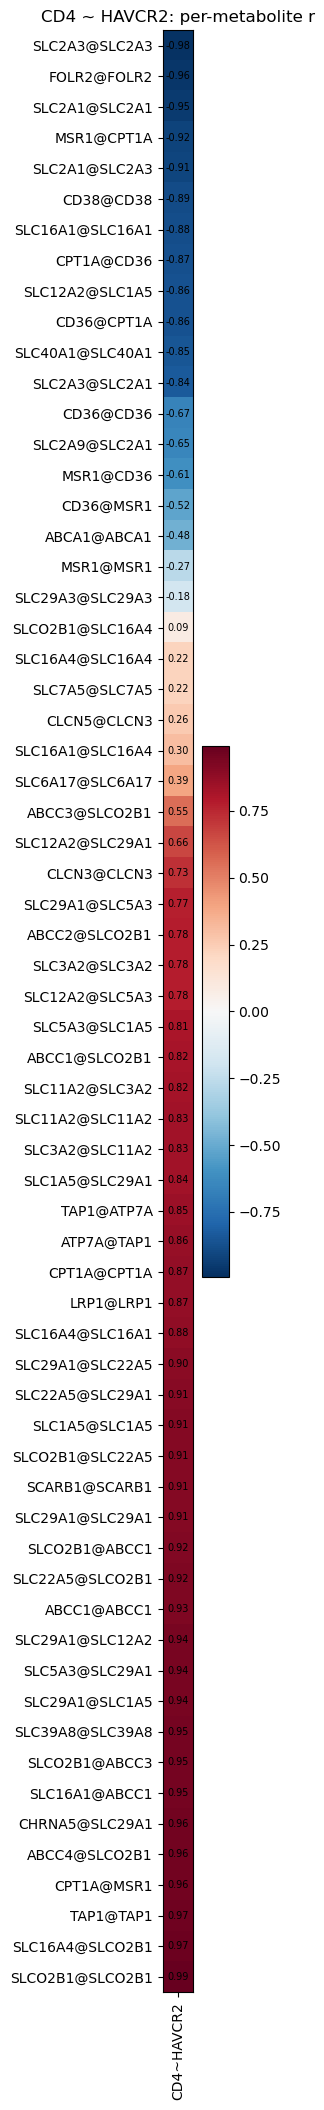

In [11]:
# Drill into the most-similar pair (largest |cosine| off the diagonal): which metabolites
# drive (or oppose) the correlation? Auto-picking a real pair avoids hard-coded indices and
# the "pair shares no modulators" empty-plot case.
g = similarity_grid(adata, genes, group="metab", standardize=True)
off = g.to_numpy().copy()
np.fill_diagonal(off, 0.0)
i, j = np.unravel_index(np.nanargmax(np.abs(off)), off.shape)
GENE_A, GENE_B = genes[i], genes[j]

v = factor_sims(adata, GENE_A, GENE_B, group="metab", standardize=True)
shared = v[v != 0].sort_values()
if shared.empty:
    print(f"{GENE_A} ~ {GENE_B}: no shared varying metabolite modulators")
else:
    plot_factor_sims(shared, title=f"{GENE_A} ~ {GENE_B}: per-metabolite r");

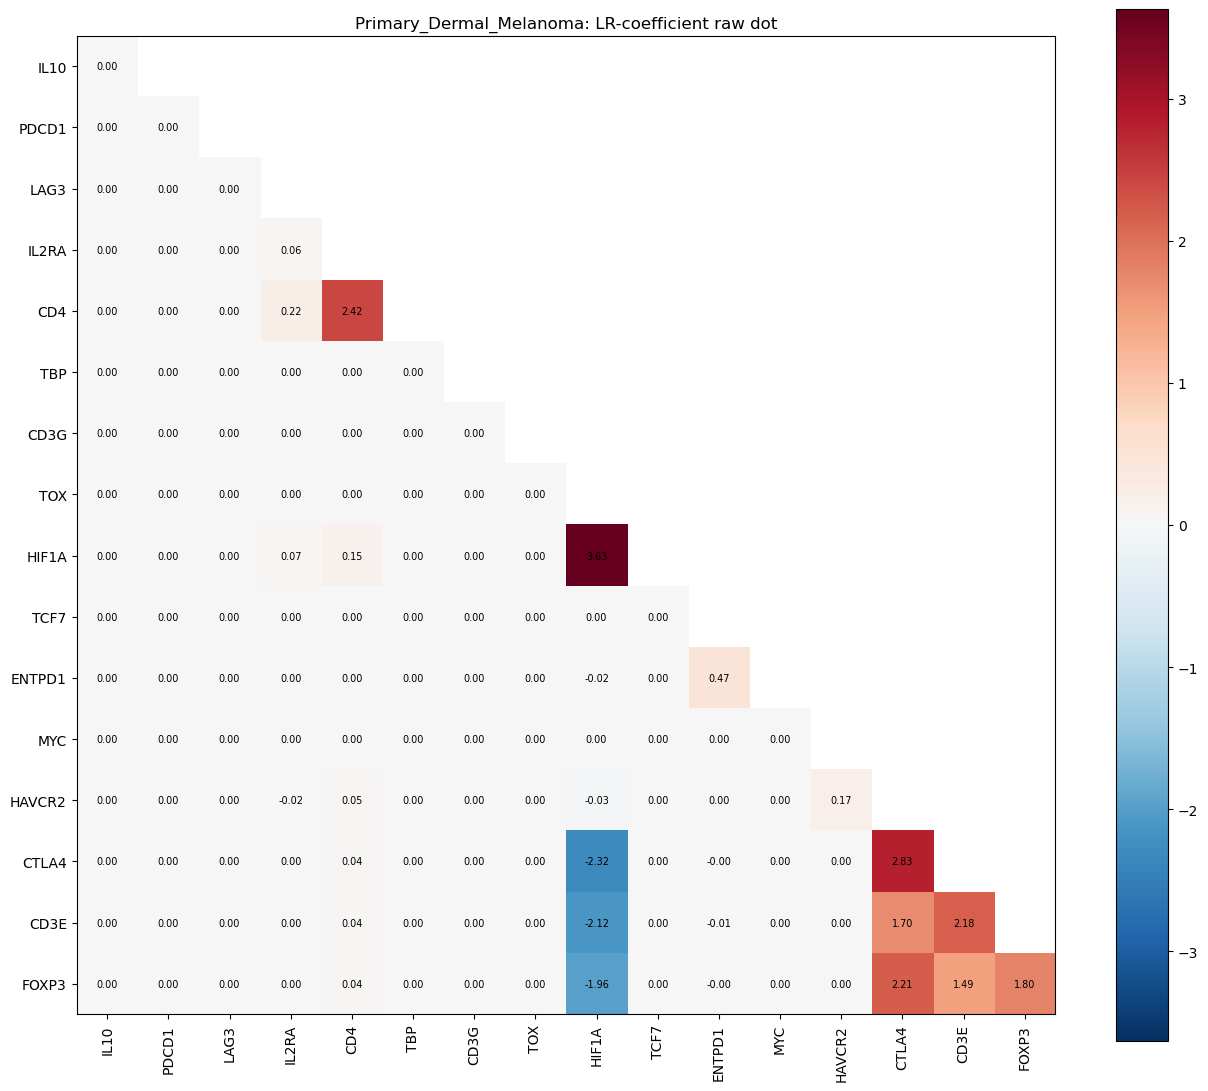

In [15]:
grid = similarity_grid(adata, genes, group="lr", standardize=False)
plot_grid(grid, title=f"{DATASET_NAME}: LR-coefficient raw dot");

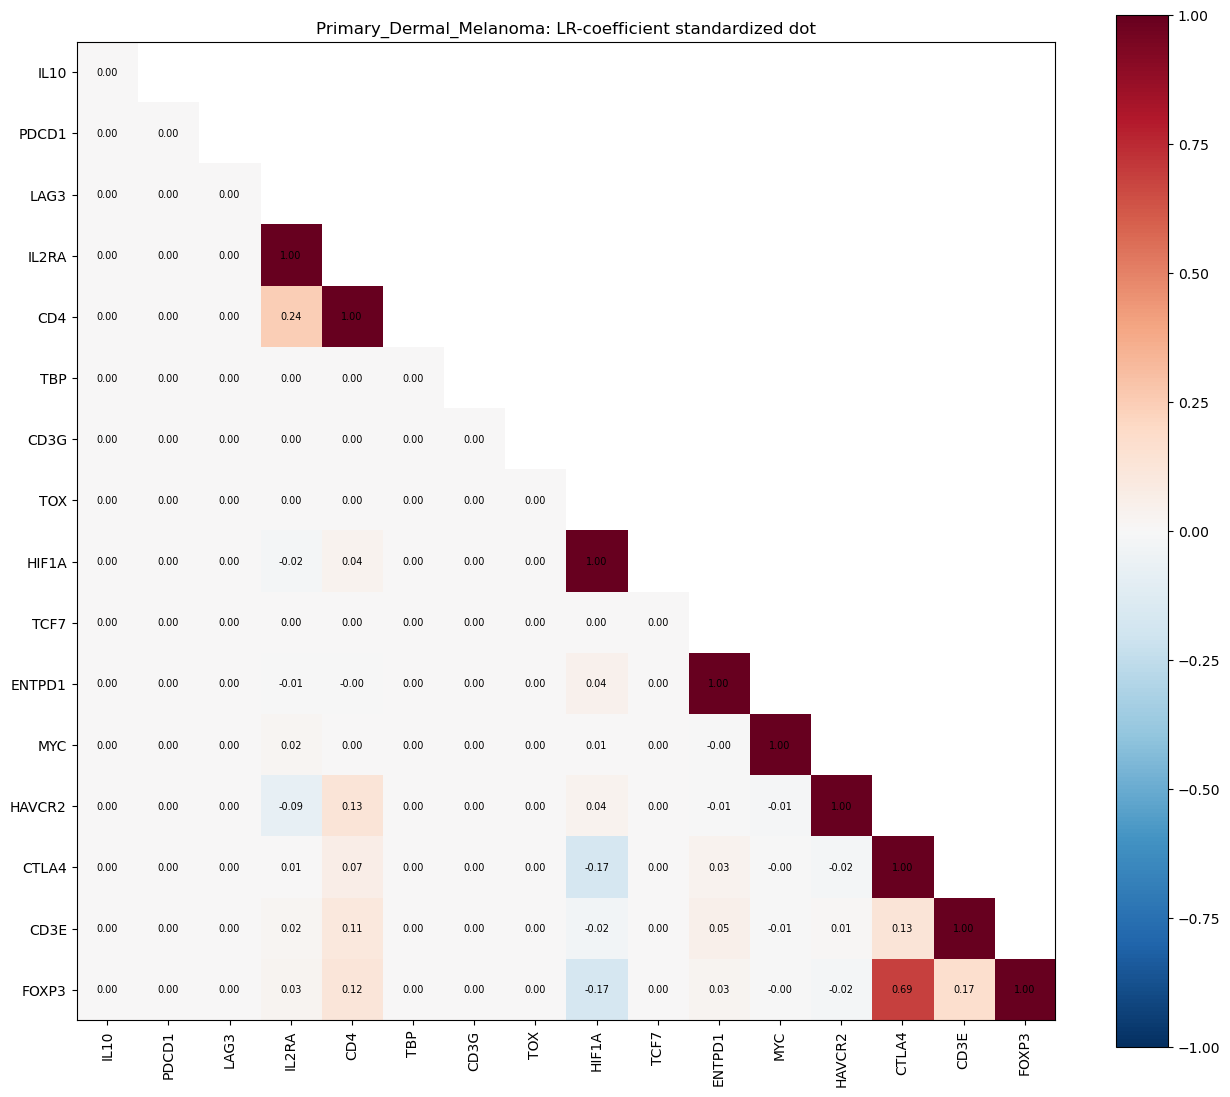

In [16]:
grid = similarity_grid(adata, genes, group="lr", standardize=True)
plot_grid(grid, title=f"{DATASET_NAME}: LR-coefficient standardized dot");

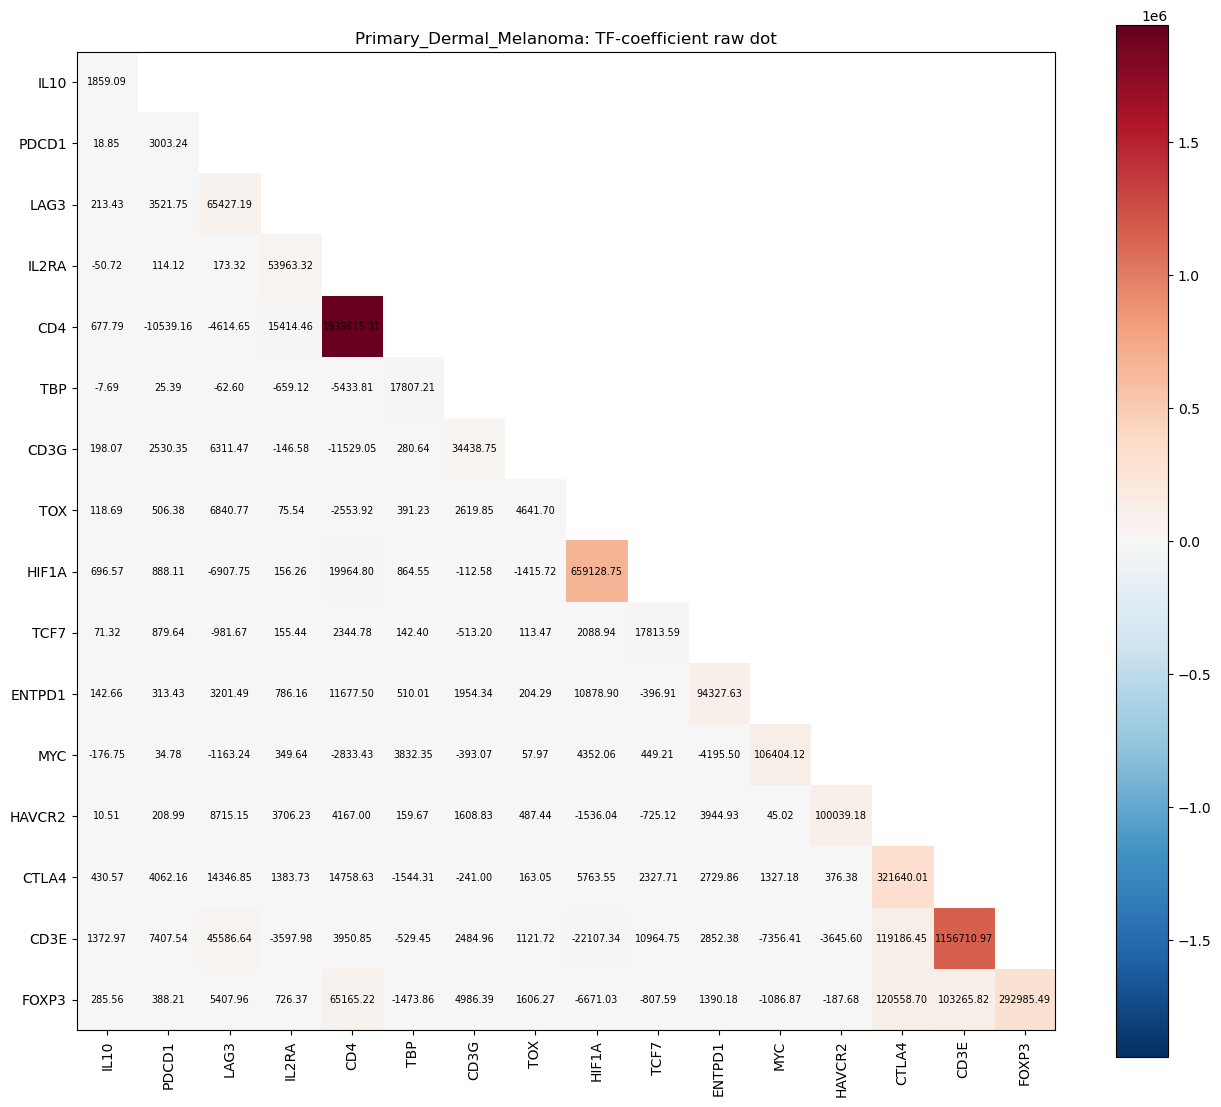

In [17]:
grid = similarity_grid(adata, genes, group="tf", standardize=False)
plot_grid(grid, title=f"{DATASET_NAME}: TF-coefficient raw dot");

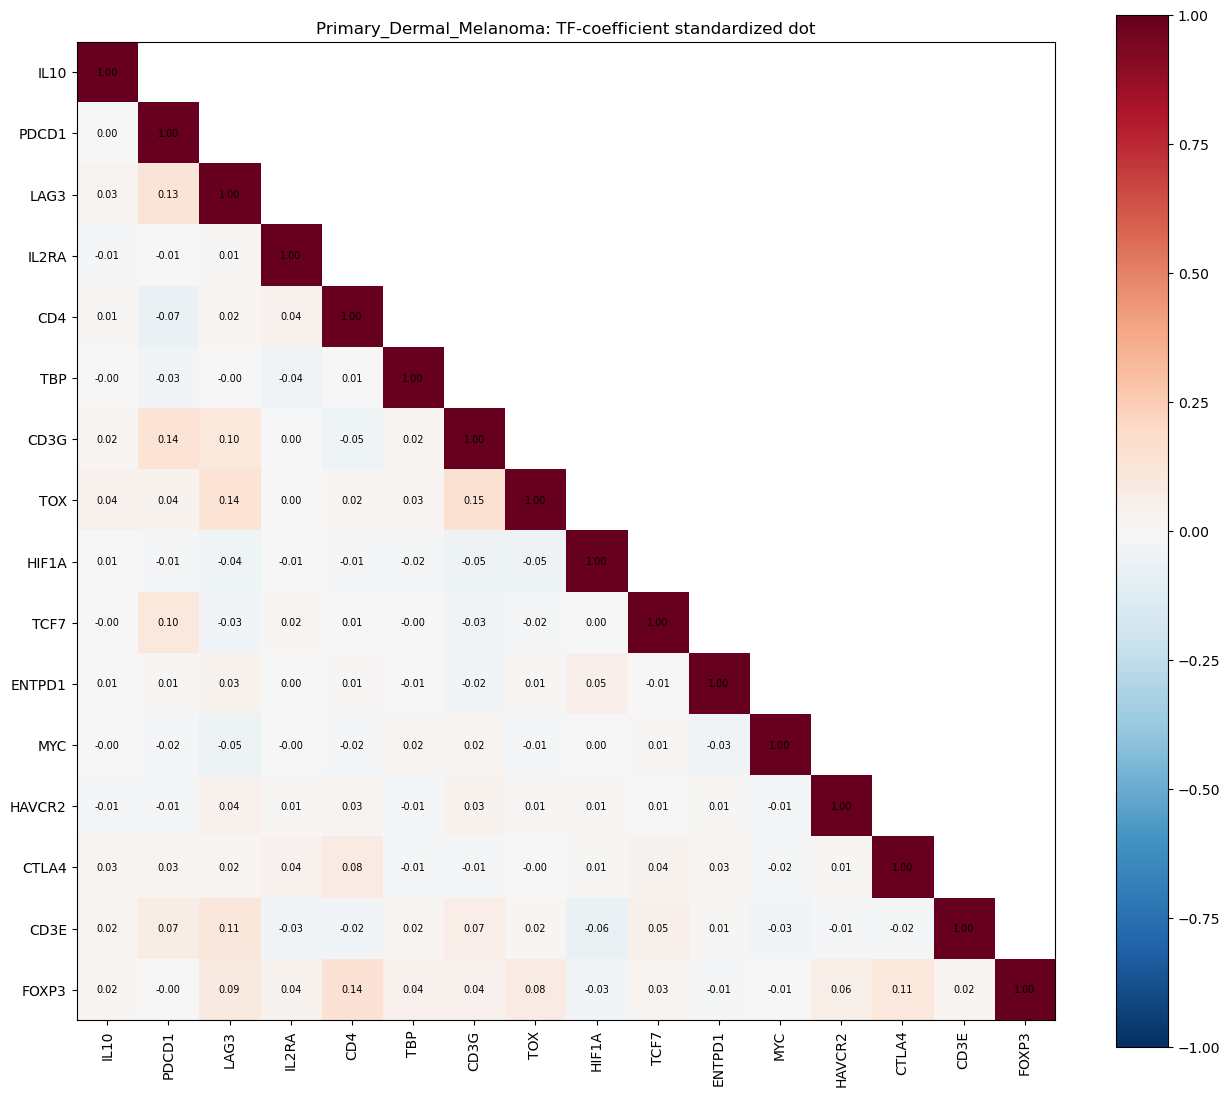

In [18]:
# Non-standardized (raw dot) grid — this is magnitude, not shape.
grid = similarity_grid(adata, genes, group="tf", standardize=True)
plot_grid(grid, title=f"{DATASET_NAME}: TF-coefficient standardized dot");